#### Imports

In [ ]:
# local imports
from dist_gen import * # if not working, move to same directory as target import. This also relied on what is now dist_gen_old

# external imports
import matplotlib.animation as anim
import matplotlib.pyplot as plt
from collections import namedtuple
import numpy as np
#import pandas as pd
#import plasmapy as plas
#import random as rd

#### 1D Particle Simulation

Particle Definition and Data Handling

Parameters

In [101]:
N_e = 5000 # number of electrons
N_i = 5000 # number of ions
x_min, x_max = -2.5e-5, 2.5e-5#-0.00001, 0.00001 for ion two-stream
v_min, v_max = -250000, 250000#-500, 500 ditto
dt = 0.000000000025 #0.000000005
e = 1.602e-19
m_e = 9.10938188e-31
m_p = 1.67262158e-27
k = 8.987e9
E_resolution = 1000
smooth = 0.0001
sq_window_res = 250

# computed constants
width = x_max - x_min

def x_dist(x) -> float:
    return 1

def v_dist(v) -> float:
    return np.e**-((20*((v/v_max)-0.25))**2) + np.e**-((20*((v/v_max)+0.25))**2)

def x_dist_e(x) -> float:
    return np.e**-((5*((x/x_max)))**2)

def v_dist_e(v) -> float:
    return np.e**-((10*((v/v_max)))**2)

def x_dist_i(x) -> float:
    return np.e**-((5*((x/x_max)))**2)

def v_dist_i(v) -> float:
    if np.abs(v) < 0.01*(v_max-v_min):
        return 1
    return 0

In [102]:
# particle data
name_list: list = []
pos_list:  list = []
vel_list:  list = []
acc_list:  list = []
chg_list:  list = []
mass_list: list = []

lists: list = [name_list, pos_list, vel_list, acc_list, chg_list, mass_list]

name_arr: np.array = np.array(1)
pos_arr: np.array = np.array(1)
vel_arr: np.array = np.array(1)
acc_arr: np.array = np.array(1)
chg_arr: np.array = np.array(1)
mass_arr: np.array = np.array(1)

E_field: np.array = np.zeros(E_resolution)

def add_particles(particle: dict, n: int, x_d: function = x_dist, v_d: function = v_dist) -> None:
    for i in range(n):
        name_list.append(particle["name"])
        pos_list.append(rand_from_dist(x_d, x_min, x_max, 100/x_max, True))
        vel_list.append(rand_from_dist(v_d, v_min, v_max, 100/v_max, True))
        acc_list.append(0)
        chg_list.append(particle["charge"])
        mass_list.append(particle["mass"])

def data_to_arrays() -> None:
    global name_list, pos_list, vel_list, acc_list, chg_list, mass_list
    global name_arr, pos_arr, vel_arr, acc_arr, chg_arr, mass_arr
    name_arr = np.array(name_list)
    pos_arr = np.array(pos_list)
    vel_arr = np.array(vel_list)
    acc_arr = np.array(acc_list)
    chg_arr = np.array(chg_list)
    mass_arr = np.array(mass_list)

def kinetic_energy() -> float:
    return np.sum(mass_arr*(vel_arr**2)/2)

In [103]:
electron: dict = {
    "name": "Electron",
    "charge": -1*e,
    "mass": m_e
}

ion: dict = {
    "name": "Ion",
    "charge": 1*e,
    "mass": m_p
}

Simulation Functions

In [104]:
def init() -> None:
    global lists
    for i in range(len(lists)):
        lists[i].clear()
    add_particles(electron, N_e, x_dist, v_dist)
    add_particles(ion, N_i, x_dist, v_dist)
    data_to_arrays()

def E(x) -> float: # electric field
    field_idx = int(E_resolution * (x-x_min) / width)
    if field_idx == E_resolution:
        field_idx -= 1
    if field_idx >= 0 and field_idx < len(E_field):
        return E_field[field_idx]
    print(f"ERROR:\n{x} not in range [{x_min}, {x_max}).\nField Index: {field_idx}")
    raise Exception("Tried to access field cell outside of defined window [x_min, x_max)")

def upd_accelerations() -> None:
    for i in range(len(name_arr)):
        acc_arr[i] = chg_arr[i] * E(pos_arr[i]) / mass_arr[i]

def compute_E_cell(i: int) -> float:
    field = 0
    cell_position = (i * width / E_resolution) + x_min
    N = len(name_arr)
    for j in range(N):
        dist = pos_arr[j] - cell_position
        field += k * np.sign(dist) * chg_arr[j]/(dist**2 + smooth**2)
    return field

def upd_E_field() -> None:
    #for i in range(len(E_field)):
    #    E_field[i] = compute_E_cell(i)

    cell_space = np.linspace(x_min, x_max, E_resolution, endpoint = False)
    dx = pos_arr[:, None] - cell_space[None, :]
    #periodic wrap
    dx -= width * np.round(dx / width)
    
    E_field[:] = np.sum(
        k * np.sign(dx) * chg_arr[:, None] / (dx**2 + smooth**2),
        axis=0
    )

def step(frame):
    global ax
    pos_arr_e = pos_arr[name_arr == "Electron"]
    vel_arr_e = vel_arr[name_arr == "Electron"]
    pos_arr_i = pos_arr[name_arr == "Ion"]
    vel_arr_i = vel_arr[name_arr == "Ion"]
    ax.clear()
    print("Current frame: " + str(frame), end="\x1b[1K\r")
    ax.hist2d(pos_arr_e, vel_arr_e, bins=sq_window_res, range=[[x_min, x_max], [v_min, v_max]], cmap='hot')
    N = len(name_arr)
    for i in range(N):
        pos_arr[i] += vel_arr[i] * dt + 0.5 * acc_arr[i] * dt**2
        pos_arr[i] = x_min + ((pos_arr[i] - x_min) % width)
    upd_E_field()
    upd_accelerations()
    for i in range(N):
        vel_arr[i] += acc_arr[i] * dt
    ax.set_title("t = " + str(float(f'{frame*dt:.9f}')))

Creating an Animation

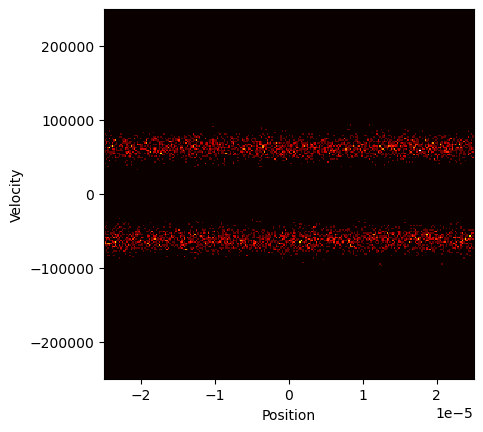

In [105]:
init()

pos_arr_e = pos_arr[name_arr == "Electron"]
vel_arr_e = vel_arr[name_arr == "Electron"]
pos_arr_i = pos_arr[name_arr == "Ion"]
vel_arr_i = vel_arr[name_arr == "Ion"]

fig, ax = plt.subplots()
plt.hist2d(pos_arr_e, vel_arr_e, bins=sq_window_res, range=[[x_min, x_max], [v_min, v_max]], cmap='hot')
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_box_aspect(1)

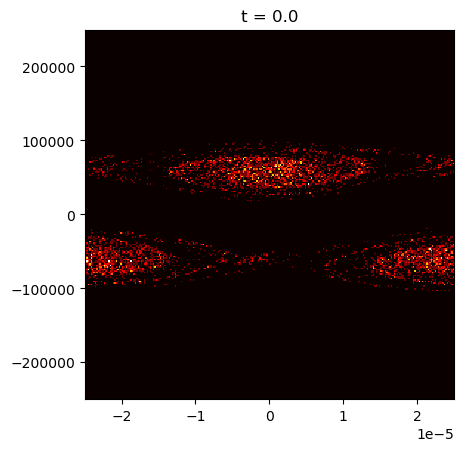

In [106]:
fig, ax = plt.subplots()
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_box_aspect(1)

ani = anim.FuncAnimation(fig=fig, func=step, frames=250, interval=25)
ani.save("first_sim.gif")